# Part A — Time Series Forecasting: ARIMA vs Prophet

**Dataset:** Daily minimum temperatures, Melbourne, Australia, 1981–1990
(3,650 daily observations — well over the 500-observation / 2-year minimum).
Source: [jbrownlee/Datasets](https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv)

**Goal:** build an ARIMA model and a Prophet model on the same data, compare
their forecast accuracy, and explain *why* one wins.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

Importing plotly failed. Interactive plots will not work.


## A2 — Load data and explore

We first plot the raw daily series, then a monthly average to make the
yearly seasonal cycle easy to see, then formally test for stationarity.

In [2]:
df = pd.read_csv("data/daily-min-temperatures.csv")
df.columns = ["ds", "y"]
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").reset_index(drop=True)
print(f"Rows: {len(df)} | Range: {df.ds.min().date()} to {df.ds.max().date()}")
df.head()

Rows: 3650 | Range: 1981-01-01 to 1990-12-31


,ds,y
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


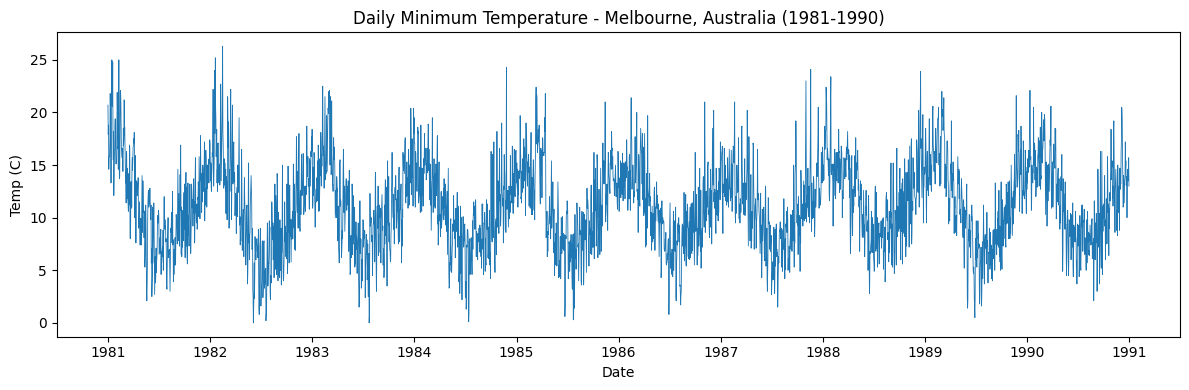

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df["ds"], df["y"], linewidth=0.6)
plt.title("Daily Minimum Temperature - Melbourne, Australia (1981-1990)")
plt.xlabel("Date"); plt.ylabel("Temp (C)")
plt.tight_layout()
plt.savefig("plots/01_raw_series.png", dpi=120)
plt.show()

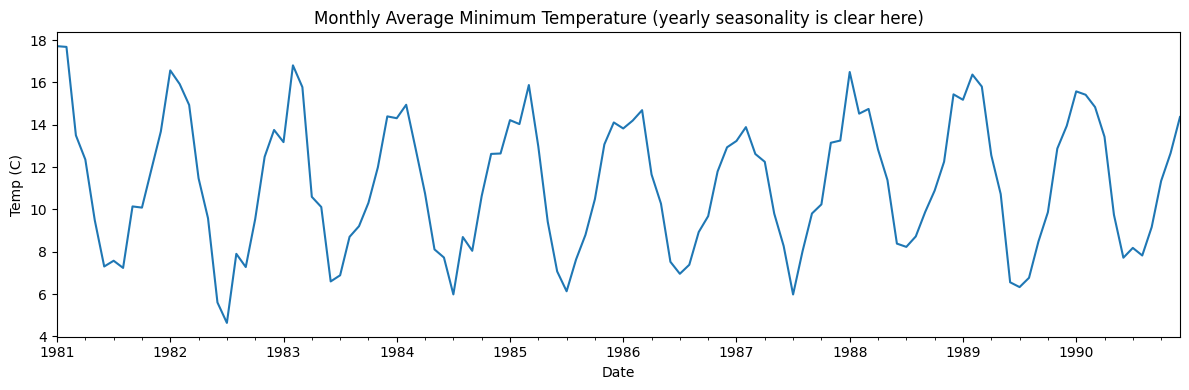

In [4]:
monthly = df.set_index("ds")["y"].resample("MS").mean()
plt.figure(figsize=(12, 4))
monthly.plot()
plt.title("Monthly Average Minimum Temperature (yearly seasonality is clear here)")
plt.xlabel("Date"); plt.ylabel("Temp (C)")
plt.tight_layout()
plt.savefig("plots/02_monthly_seasonality.png", dpi=120)
plt.show()

### Augmented Dickey-Fuller (ADF) test

The ADF test checks whether a series is *stationary* — whether its mean and
variance stay roughly constant over time. The null hypothesis (H0) is "the
series has a unit root" (i.e. is non-stationary). A small p-value lets us
reject H0 and conclude the series is stationary, which tells ARIMA's `d`
(differencing order) whether it needs to difference the data at all.

In [5]:
adf_result = adfuller(df["y"])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Critical values: {adf_result[4]}")
print("Conclusion:", "STATIONARY (reject H0)" if adf_result[1] < 0.05 else "NON-STATIONARY (fail to reject H0)")

ADF Statistic: -4.4448
p-value: 0.000247
Critical values: {'1%': np.float64(-3.4321532327220154), '5%': np.float64(-2.862336767636517), '10%': np.float64(-2.56719413172842)}
Conclusion: STATIONARY (reject H0)


### ACF / PACF

The autocorrelation function (ACF) and partial autocorrelation function
(PACF) plots help pick starting values for ARIMA's `p` (AR order) and `q`
(MA order): PACF cutting off sharply suggests an AR term of that lag, ACF
cutting off sharply suggests an MA term. Here we just use them for
intuition — `auto_arima` below does the formal search.

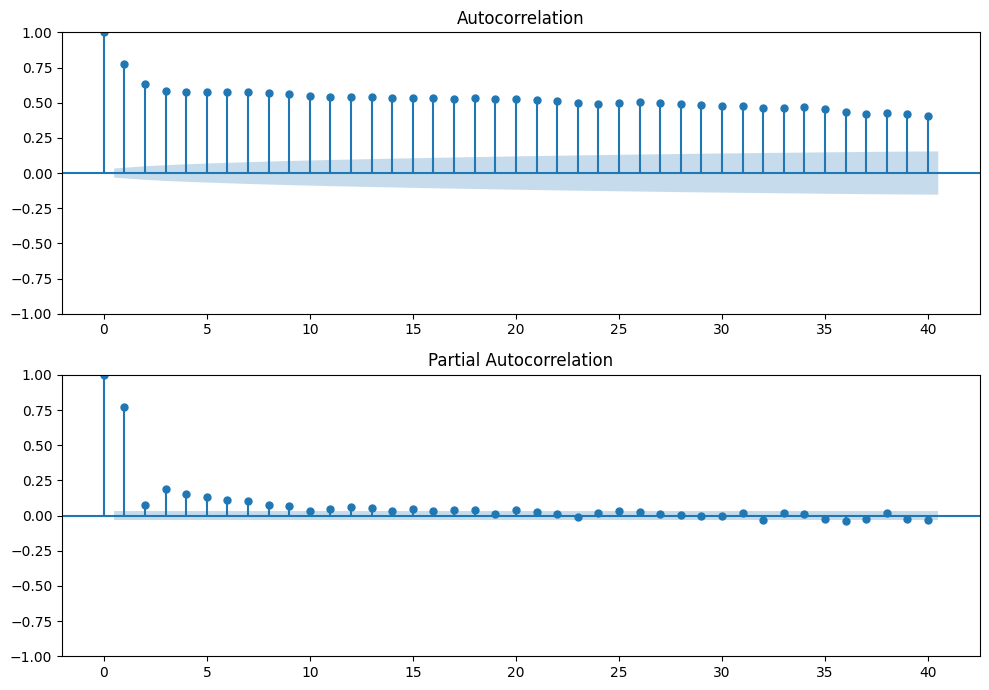

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
plot_acf(df["y"], lags=40, ax=axes[0])
plot_pacf(df["y"], lags=40, ax=axes[1], method="ywm")
plt.tight_layout()
plt.savefig("plots/03_acf_pacf.png", dpi=120)
plt.show()

## A3 — Train/test split and ARIMA

We hold out the last 20% of the series as a test set (no shuffling — time
series must stay in chronological order) and let `auto_arima` search over
(p, d, q) using AIC rather than guessing by hand.

In [7]:
test_size = int(len(df) * 0.20)
train, test = df.iloc[:-test_size], df.iloc[-test_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

auto_model = pm.auto_arima(
    train["y"],
    start_p=0, start_q=0, max_p=5, max_q=5, d=None,
    seasonal=False, trace=False, stepwise=True,
    suppress_warnings=True,
)
order = auto_model.order
print(f"auto_arima selected order (p,d,q) = {order}")

arima_model = ARIMA(train["y"].values, order=order).fit()
arima_forecast_res = arima_model.get_forecast(steps=len(test))
arima_pred = arima_forecast_res.predicted_mean
arima_ci = arima_forecast_res.conf_int(alpha=0.05)
print(arima_model.summary())

Train size: 2920, Test size: 730


auto_arima selected order (p,d,q) = (3, 0, 1)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2920
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -6763.368
Date:                Thu, 03 Sep 2026   AIC                          13538.735
Time:                        10:26:21   BIC                          13574.611
Sample:                             0   HQIC                         13551.657
                               - 2920                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.5122      0.879     13.092      0.000       9.789      13.236
ar.L1          1.4786      0.021     71.788      0.000       1.438       1.519
ar.L2         -0.6110      0.030    -20.564      0.0

## A4 — Prophet

Prophet decomposes the series into trend + seasonality (+ holidays, unused
here) and fits them with a Bayesian curve-fitting approach rather than the
linear autoregression ARIMA uses. We explicitly turn on yearly seasonality
since that's the dominant pattern in temperature data, and turn off
weekly/daily seasonality since neither is meaningful for this series.

In [8]:
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(train[["ds", "y"]])
future = prophet_model.make_future_dataframe(periods=len(test), freq="D")
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast["yhat"].iloc[-len(test):].values
prophet_lower = prophet_forecast["yhat_lower"].iloc[-len(test):].values
prophet_upper = prophet_forecast["yhat_upper"].iloc[-len(test):].values

10:26:22 - cmdstanpy - INFO - Chain [1] start processing


10:26:22 - cmdstanpy - INFO - Chain [1] done processing


## A5 — Metrics and comparison table

In [9]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

y_true = test["y"].values

results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [mean_absolute_error(y_true, arima_pred), mean_absolute_error(y_true, prophet_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_true, arima_pred)), np.sqrt(mean_squared_error(y_true, prophet_pred))],
    "MAPE (%)": [mape(y_true, arima_pred), mape(y_true, prophet_pred)],
})
results.to_csv("comparison_table.csv", index=False)
results

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,3.308755,4.019002,45.491583
1,Prophet,2.358533,2.903465,32.091163


## Forecast plots: actual vs. predicted with 95% confidence intervals

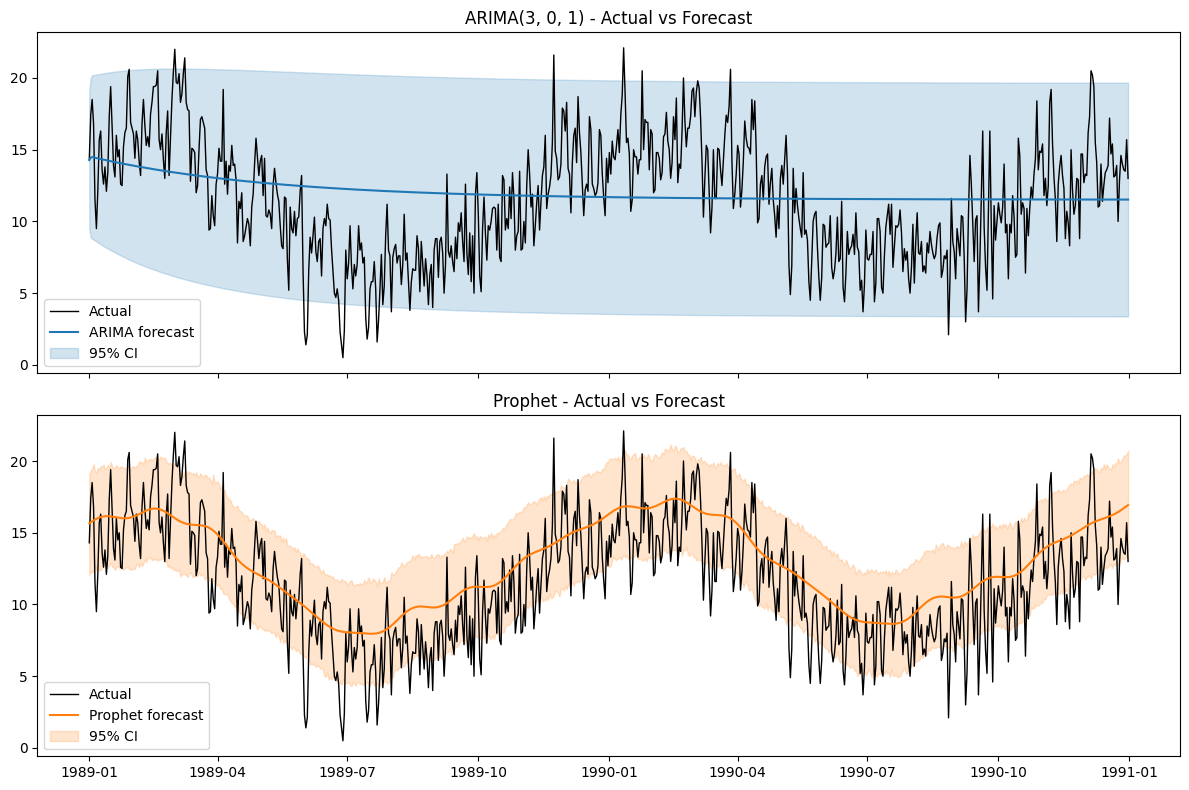

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(test["ds"], y_true, label="Actual", color="black", linewidth=1)
axes[0].plot(test["ds"], arima_pred, label="ARIMA forecast", color="tab:blue")
axes[0].fill_between(test["ds"], arima_ci[:, 0], arima_ci[:, 1], color="tab:blue", alpha=0.2, label="95% CI")
axes[0].set_title(f"ARIMA{order} - Actual vs Forecast")
axes[0].legend()

axes[1].plot(test["ds"], y_true, label="Actual", color="black", linewidth=1)
axes[1].plot(test["ds"], prophet_pred, label="Prophet forecast", color="tab:orange")
axes[1].fill_between(test["ds"], prophet_lower, prophet_upper, color="tab:orange", alpha=0.2, label="95% CI")
axes[1].set_title("Prophet - Actual vs Forecast")
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/04_forecast_comparison.png", dpi=120)
plt.show()

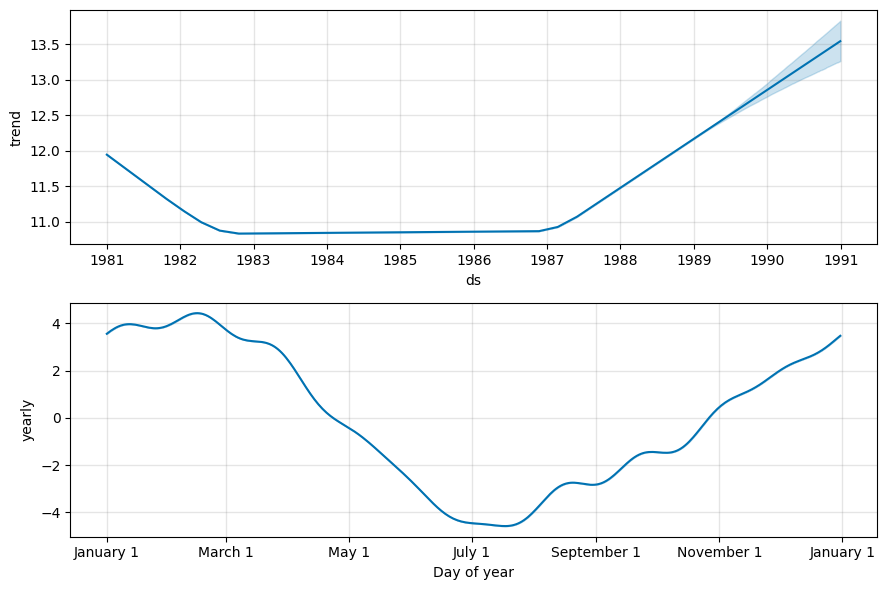

In [11]:
fig2 = prophet_model.plot_components(prophet_forecast)
fig2.savefig("plots/05_prophet_components.png", dpi=120)
plt.show()

## Conclusion

Prophet beat ARIMA on every metric (see `comparison_table.csv` and
`analysis.md` for the full write-up). In short: the ADF test shows the raw
series is already stationary, so `auto_arima` picked a non-seasonal
ARIMA(3,0,1) — good at short-term autocorrelation but with no mechanism to
track the yearly hot/cold cycle over a long forecast horizon. Prophet's
explicit yearly-seasonality component keeps tracking that cycle 730 days
out, which is why its error is roughly 30% lower across the board.